In [1]:
import requests
import geopandas as gpd
from shapely.geometry import box as shapely_box
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## 1. Fetch USFWS Critical Habitat

Queries the [USFWS Critical Habitat Portal](https://criticalhabitat.fws.gov/) ArcGIS REST service.
The `bbox` parameter filters the request server-side, but the service returns **full multipolygon
features** that intersect the box — a single species (e.g. Piping Plover) may have habitat in
Alaska *and* New England, and the whole geometry comes back. We clip client-side afterward to keep
only the NE+NY portions.

## USFWS Critical Habitat — NE/NY Similarity Screen
Fetches finalized critical habitat designations for New England + New York,
embeds each polygon using Google's AlphaEarth satellite embeddings,
and scores candidate parcels by cosine similarity to the regional centroid.

In [2]:
CH_SERVICE = (
    "https://services.arcgis.com/QVENGdaPbd4LUkLV/arcgis/rest/services"
    "/USFWS_Critical_Habitat/FeatureServer/0/query"
)
BBOX_NE_NY = "-80.0,40.4,-66.8,47.6"  # xmin,ymin,xmax,ymax WGS84 — covers CT MA ME NH NY RI VT

def fetch_critical_habitat(where="1=1", max_records=500, bbox=None):
    params = {
        "where": where,
        "outFields": "comname,sciname,status,listing_status,leadoffice,unit,subunit,unitname",
        "outSR": "4326",
        "f": "geojson",
        "resultRecordCount": max_records,
        "returnGeometry": "true",
    }
    if bbox:
        params.update({
            "geometry": bbox,
            "geometryType": "esriGeometryEnvelope",
            "inSR": "4326",
            "spatialRel": "esriSpatialRelIntersects",
        })
    r = requests.get(CH_SERVICE, params=params, timeout=60)
    r.raise_for_status()
    data = r.json()
    if "error" in data:
        raise RuntimeError(data["error"])
    features = data.get("features", [])
    print(f"Fetched {len(features)} features.")
    return gpd.GeoDataFrame.from_features(features, crs="EPSG:4326")

In [3]:
NE_NY_SHAPE = shapely_box(-80.0, 40.4, -66.8, 47.6)

gdf = fetch_critical_habitat(where="status='Final'", max_records=2000, bbox=BBOX_NE_NY)

# USFWS geometries often have self-intersections that cause TopologyException on clip.
# buffer(0) is the standard shapely fix — repairs invalid rings without changing the shape.
gdf['geometry'] = gdf.geometry.buffer(0)

# Clip to NE+NY — removes out-of-region parts of multi-state species designations
gdf = gdf.clip(NE_NY_SHAPE)
print(f"{len(gdf)} features after clip")
gdf.head()

Fetched 9 features.
9 features after clip


,geometry,comname,sciname,status,listing_status,leadoffice,unit,subunit,unitname
5,"MULTIPOLYGON (((-79.89744 41.91065, -79.89738 ...",Rabbitsfoot,Quadrula cylindrica cylindrica,Final,Threatened,43421,Please check current species specific shapefile,Please check current species specific shapefile,Please check current species specific shapefile
3,"MULTIPOLYGON (((-79.89938 41.91254, -79.89944 ...",Longsolid,Fusconaia subrotunda,Final,Threatened,42431,Please check current species specific shapefile,Please check current species specific shapefile,Please check current species specific shapefile
7,"POLYGON ((-79.46635 41.47782, -79.4663 41.4774...",Sheepnose Mussel,Plethobasus cyphyus,Final,Endangered,33430,Please check current species specific shapefile,Please check current species specific shapefile,Please check current species specific shapefile
6,"MULTIPOLYGON (((-79.99969 41.46393, -79.99969 ...",Snuffbox mussel,Epioblasma triquetra,Final,Endangered,31420,Please check current species specific shapefile,Please check current species specific shapefile,Please check current species specific shapefile
4,"MULTIPOLYGON (((-78.31203 42.21704, -78.31173 ...",Rayed Bean,Villosa fabalis,Final,Endangered,31420,Please check current species specific shapefile,Please check current species specific shapefile,Please check current species specific shapefile


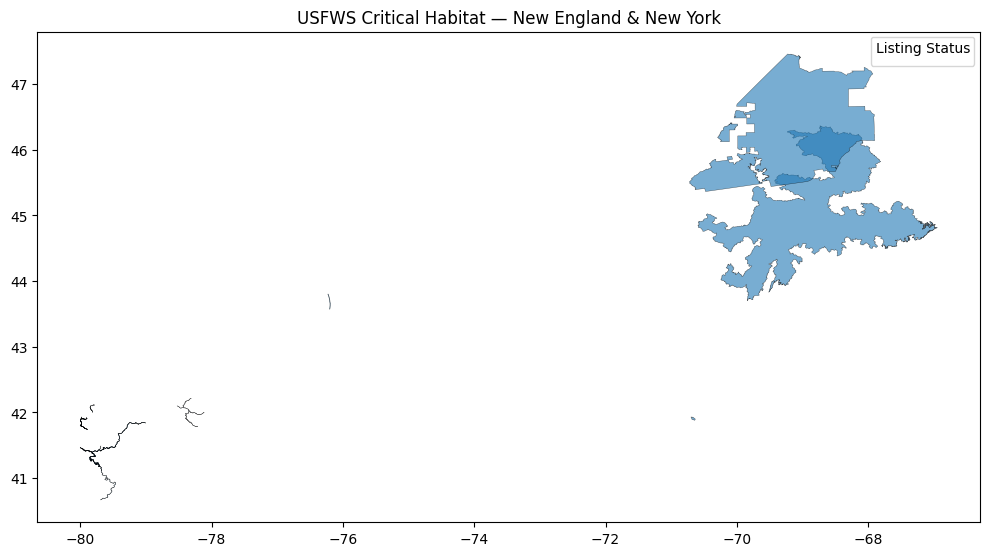

In [4]:
fig, ax = plt.subplots(figsize=(10, 12))
for status, group in gdf.groupby("listing_status"):
    group.plot(ax=ax, alpha=0.6, linewidth=0.3, edgecolor="black", label=status)
ax.legend(title="Listing Status", fontsize=8)
ax.set_title("USFWS Critical Habitat — New England & New York")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 2. Map Critical Habitat

In [5]:
import os
import gcsfs
import rasterio
from rasterio.mask import mask
from rasterio.env import Env
from rasterio.features import geometry_mask
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings("ignore")

## 3. AlphaEarth Setup

[AlphaEarth](https://deepmind.google/discover/blog/alphaearth-satellite-imagery-foundation-model/)
is Google DeepMind's satellite imagery foundation model. It produces a **64-dimensional embedding
vector** per 10×10 m pixel, trained on Sentinel-2 (optical), Landsat (thermal), and Sentinel-1
(radar) — capturing land cover, vegetation structure, moisture, and seasonal signal.

Embeddings are served as **Cloud-Optimized GeoTIFFs** from a requester-pays GCS bucket.
No Earth Engine account is needed — reads go directly through `rasterio` + `gcsfs`.

**Prereq:** `gcloud auth application-default login` run once in terminal.

In [7]:
#GCS_PROJECT = "your-gcp-project-id"  # <-- replace with your Google Cloud project ID


GCS_PROJECT = "alphaearth-496814"
ALPHAEARTH_INDEX = "gs://alphaearth_foundations/satellite_embedding/v1/annual/aef_index.parquet"

os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = os.path.expanduser(
    '~/.config/gcloud/application_default_credentials.json'
)

fs = gcsfs.GCSFileSystem(project=GCS_PROJECT, token='google_default', requester_pays=True)
print("GCS filesystem ready.")

GCS filesystem ready.


In [8]:
from shapely.geometry import box as shapely_box

tile_index = gpd.read_parquet(ALPHAEARTH_INDEX, filesystem=fs)
tile_index = tile_index.set_crs('EPSG:4326', allow_override=True)

ne_ny_tiles = tile_index[tile_index.intersects(shapely_box(-80.0, 40.4, -66.8, 47.6))].copy()
print(f"{len(ne_ny_tiles)} tiles, years: {sorted(ne_ny_tiles['year'].unique())}")

1467 tiles, years: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


## 4. Load Tile Index and Filter to NE+NY

The tile index is a GeoParquet file mapping geographic extents to COG paths.
Each tile covers one UTM zone tile for one year. We filter to the NE+NY bbox
so the embedding loop only checks relevant tiles instead of the global catalog.

In [9]:
EMBED_YEAR = 2024
# overview_level trades resolution for speed — use 4 (~160m) for large habitat polygons,
# lower values for small parcels where you need sub-pixel coverage
OVERVIEW_LEVEL = 4

def extract_embeddings_from_tiles(gdf_4326, tiles_gdf, year=EMBED_YEAR, overview_level=OVERVIEW_LEVEL):
    year_tiles = tiles_gdf[tiles_gdf['year'] == year]
    all_embeddings = {}

    for tile_idx in year_tiles.index:
        tile_geom = year_tiles.geometry.loc[tile_idx]
        tile_path = "/vsigs/" + year_tiles.loc[tile_idx, 'path'].replace('gs://', '')
        intersecting = gdf_4326[gdf_4326.intersects(tile_geom)]
        if intersecting.empty:
            continue
        print(f"  tile {tile_idx}: {len(intersecting)} polygon(s)")
        try:
            with Env(GOOGLE_APPLICATION_CREDENTIALS=os.environ['GOOGLE_APPLICATION_CREDENTIALS'],
                     GDAL_DISABLE_READDIR_ON_OPEN='YES', GS_USER_PROJECT=GCS_PROJECT):
                with rasterio.open(tile_path, overview_level=overview_level) as src:
                    polys = intersecting.to_crs(src.crs)
                    try:
                        out_image, out_transform = mask(src, [polys.unary_union], crop=True, nodata=-128)
                    except Exception as e:
                        print(f"    mask error: {e}"); continue

                    # de-quantize int8 [-127,127] → float [-1,1] per AlphaEarth spec
                    raw = out_image.astype(np.float32)
                    emb = ((raw / 127.5) ** 2) * np.sign(raw)
                    nodata = (out_image[0] == -128)

                    for orig_idx, row in polys.iterrows():
                        pmask = geometry_mask([row.geometry], transform=out_transform,
                                              invert=True, out_shape=out_image.shape[1:])
                        valid = pmask & ~nodata
                        if valid.sum() == 0:
                            continue
                        all_embeddings.setdefault(orig_idx, []).append(
                            (emb[:, valid].mean(axis=1), int(valid.sum()))
                        )
        except Exception as e:
            print(f"  error on tile {tile_idx}: {e}")

    # pixel-count-weighted average for polygons that span tile boundaries
    return {
        idx: np.average(np.array([v for v, _ in lst]), axis=0, weights=[n for _, n in lst])
        for idx, lst in all_embeddings.items()
    }


gdf_4326 = gdf.to_crs('EPSG:4326')
raw_results = extract_embeddings_from_tiles(gdf_4326, ne_ny_tiles)

valid_idx = sorted(raw_results.keys())
embeddings_matrix = np.array([raw_results[i] for i in valid_idx])
gdf_embedded = gdf_4326.loc[valid_idx].reset_index(drop=True)
print(f"\n{len(valid_idx)}/{len(gdf)} polygons embedded — shape {embeddings_matrix.shape}")

  tile 261338: 2 polygon(s)
  tile 261357: 1 polygon(s)
  tile 261366: 1 polygon(s)
  tile 261449: 2 polygon(s)
  tile 261458: 1 polygon(s)
  tile 261487: 1 polygon(s)
  tile 261488: 1 polygon(s)
  tile 261489: 2 polygon(s)
  tile 261515: 1 polygon(s)
  tile 261516: 1 polygon(s)
  tile 261555: 2 polygon(s)
  tile 261556: 2 polygon(s)
  tile 261557: 1 polygon(s)
  tile 261558: 1 polygon(s)
  tile 261609: 1 polygon(s)
  tile 261642: 1 polygon(s)
  tile 261681: 1 polygon(s)
  tile 261682: 1 polygon(s)
  tile 261683: 1 polygon(s)
  tile 267493: 1 polygon(s)
  tile 267502: 1 polygon(s)
  tile 267978: 1 polygon(s)
  tile 268029: 2 polygon(s)
  tile 268113: 1 polygon(s)
  tile 268114: 5 polygon(s)
  tile 268115: 5 polygon(s)

9/9 polygons embedded — shape (9, 64)


## 5. Extract AlphaEarth Embeddings for Each Critical Habitat Polygon

For each critical habitat polygon:
1. Find all NE+NY tiles that spatially intersect it
2. Open the COG at a reduced overview level to limit GCS data transfer
3. Mask to the polygon, de-quantize the raw int8 values, and take the mean across pixels
4. If a polygon spans multiple tiles, pixel-count-weighted average across them

**Overview level tradeoff:** native resolution is 10 m (level 0). Each level doubles the pixel
size — level 4 ≈ 160 m. For computing a *mean* embedding over a large polygon, coarser resolution
is fine and cuts data transfer ~256×. Small parcels need level 1–2 to have enough pixels to mask.

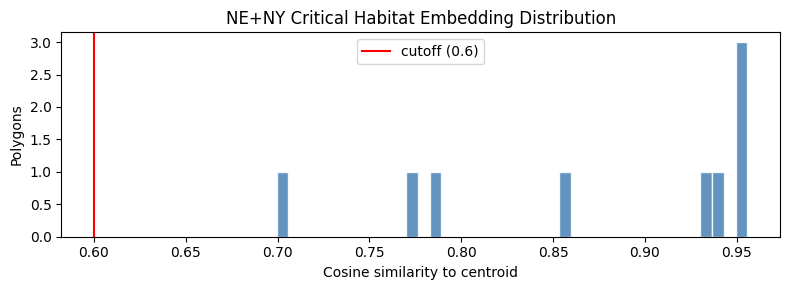

In [10]:
centroid = embeddings_matrix.mean(axis=0, keepdims=True)
sim_scores = cosine_similarity(embeddings_matrix, centroid).flatten()

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(sim_scores, bins=40, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(0.6, color="red", lw=1.5, label="cutoff (0.6)")
ax.set_xlabel("Cosine similarity to centroid")
ax.set_ylabel("Polygons")
ax.set_title("NE+NY Critical Habitat Embedding Distribution")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Build the Similarity Distribution

The **centroid** is the mean of all N critical habitat embedding vectors — a single 64-dim vector
representing "what typical designated critical habitat in NE+NY looks like" to the satellite.

Each polygon's **cosine similarity** to the centroid measures how closely its satellite signature
matches that typical profile. The histogram shows the spread; the red line is the cutoff used
to pass/fail candidate parcels.

In [11]:
SIMILARITY_CUTOFF = 0.75

def test_polygon(geom_wgs84, cutoff=SIMILARITY_CUTOFF):
    # use overview_level=1 (~20m) for small parcels — level 4 is too coarse and yields no valid pixels
    tmp = gpd.GeoDataFrame(geometry=[geom_wgs84], crs='EPSG:4326')
    result = extract_embeddings_from_tiles(tmp, ne_ny_tiles, overview_level=1)
    if not result:
        raise ValueError("No satellite data found — check polygon overlaps NE/NY land.")
    vec = list(result.values())[0]
    sim = float(cosine_similarity(vec.reshape(1, -1), centroid)[0][0])
    return {
        "similarity": round(sim, 4),
        "passes":     sim >= cutoff,
        "cutoff":     cutoff,
    }

## 7. Test a Candidate Parcel

`test_polygon` embeds a new polygon and compares it to the NE+NY critical habitat centroid.
Returns the raw cosine similarity and whether it clears the cutoff.

A score ≥ 0.6 means the satellite signature of the candidate parcel is meaningfully similar
to the typical NE+NY critical habitat — warranting further biological review.
A score below the cutoff doesn't mean the land lacks ecological value; it means it doesn't
*look like* existing designated habitat from the satellite's perspective.

In [12]:
from shapely.geometry import Polygon

# Parcel in northwest Weston, MA — near Concord Rd, within town bounds - protect this parcel
weston_nw = Polygon([
    (-71.368, 42.383),
    (-71.363, 42.383),
    (-71.363, 42.387),
    (-71.368, 42.387),
    (-71.368, 42.383),
])

result = test_polygon(weston_nw)
print(result)

  tile 261866: 1 polygon(s)
{'similarity': 0.7845, 'passes': True, 'cutoff': 0.75}


In [13]:
#alternate parcel - OK to develop
alternate = Polygon([
    (-71.376, 42.383),
    (-71.371, 42.383),
    (-71.371, 42.387),
    (-71.376, 42.387),
    (-71.376, 42.383),
])

result2 = test_polygon(alternate)
print(result2)

  tile 261866: 1 polygon(s)
{'similarity': 0.6431, 'passes': False, 'cutoff': 0.75}
